# IS 4487 Assignment 5: Exploratory Data Analysis (EDA) with Stakeholder Framing

In this assignment, you will:
- Load and explore a hotel bookings dataset
- Identify stakeholder needs and frame your analysis around business goals
- Practice data summarization and visualization
- Draw insights that could lead to actionable business recommendations

## Why This Matters

These skills are essential for business majors and minors working in areas like marketing, operations, finance, or consulting. Understanding how to explore and communicate data-driven insights helps you make better decisions and contribute to real-world business outcomes.

<a href="https://colab.research.google.com/github/Stan-Pugsley/is_4487_base/blob/main/Assignments/assignment_05_eda.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>


## Dataset Description: Hotel Bookings

This dataset contains booking information for two types of hotels: a **city hotel** and a **resort hotel**. Each record corresponds to a single booking and includes various details about the reservation, customer demographics, booking source, and whether the booking was canceled.

**Source**: [GitHub - TidyTuesday: Hotel Bookings](https://github.com/rfordatascience/tidytuesday/blob/master/data/2020/2020-02-11/readme.md)

### Key Use Cases
- Understand customer booking behavior
- Explore factors related to cancellations
- Segment guests based on booking characteristics
- Compare city vs. resort hotel performance

### Data Dictionary

| Variable | Type | Description |
|----------|------|-------------|
| `hotel` | character | Hotel type: City or Resort |
| `is_canceled` | integer | 1 = Canceled, 0 = Not Canceled |
| `lead_time` | integer | Days between booking and arrival |
| `arrival_date_year` | integer | Year of arrival |
| `arrival_date_month` | character | Month of arrival |
| `stays_in_weekend_nights` | integer | Nights stayed on weekends |
| `stays_in_week_nights` | integer | Nights stayed on weekdays |
| `adults` | integer | Number of adults |
| `children` | integer | Number of children |
| `babies` | integer | Number of babies |
| `meal` | character | Type of meal booked |
| `country` | character | Country code of origin |
| `market_segment` | character | Booking source (e.g., Direct, Online TA) |
| `distribution_channel` | character | Booking channel used |
| `is_repeated_guest` | integer | 1 = Repeated guest, 0 = New guest |
| `previous_cancellations` | integer | Past booking cancellations |
| `previous_bookings_not_canceled` | integer | Past bookings not canceled |
| `reserved_room_type` | character | Initially reserved room type |
| `assigned_room_type` | character | Room type assigned at check-in |
| `booking_changes` | integer | Number of booking modifications |
| `deposit_type` | character | Deposit type (No Deposit, Non-Refund, etc.) |
| `agent` | character | Agent ID who made the booking |
| `company` | character | Company ID (if booking through company) |
| `days_in_waiting_list` | integer | Days on the waiting list |
| `customer_type` | character | Booking type: Contract, Transient, etc. |
| `adr` | float | Average Daily Rate (price per night) |
| `required_car_parking_spaces` | integer | Requested parking spots |
| `total_of_special_requests` | integer | Number of special requests made |
| `reservation_status` | character | Final status (Canceled, No-Show, Check-Out) |
| `reservation_status_date` | date | Date of the last status update |

This dataset is ideal for classification, segmentation, and trend analysis exercises.


## 1. Setup and Data Loading

Instructions:
- Import `pandas`, `seaborn`, and `matplotlib.pyplot`.
- Import data from the hotels dataset into a dataframe (in GitHub go to the DataSets folder and look for `hotels.csv`)
- Display the first few rows to confirm it loaded correctly.


In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

csv_url = 'https://raw.githubusercontent.com/Stan-Pugsley/is_4487_base/main/DataSets/hotels.csv'
df = pd.read_csv(csv_url)

display(df.head())

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


## 2. Stakeholder and Business Context

### Business framing:  

Every analysis should serve a decision-maker. Before you explore the data, identify who cares about hotel booking behavior and what they might want to know. Your analysis should be framed around those needs.

### In Your Response:
1. Who are the key stakeholders for this dataset?
2. What goals might each stakeholder have?
3. What is a clear, specific business problem statement that this data can help answer?





### ✍️ Your Response: 🔧
1. The key stakeholders for this dataset are the hotel executives, general managers, revenue managers, finance analysts, operations managers, scheduling supervisors, marketing managers, sales directors, BI analysts, etc.

2. Hotel management would like to reduce cancellations, improve occupancy, and increase revenue per room. Revenue management would like to predict demand, optimize Average Daily Rate (ADR), and manage overbooking risk. Operations needs to plan staffing arrival dates, length of stay, and parking needs. Marketing needs to identify high-value customer tyoes and booking channels. Data analysts goals would be to build predictive models for cancellations, demand, and revenue.

3. Hotel management wants to reduce revenue loss from last-minute cancellations while maintaining high occupancy rates. Using booking lead time, customer type, deposit type, arrival timing, and historical cancellation behavior, the hotel seeks to predict which reservations are most likely to be canceled and adjust pricing, deposit requirements, and overbooking strategies accordingly.




## 3. Explore Data Structure and Quality

### Business framing:  

Before diving into analysis, analysts need to understand the shape and health of the data. Bad data leads to bad decisions.

### Do the following:
- Perform the following 3 checks to see the data quality:
  - Summary the data (e.g., `.info()`, `.describe()`)
  - Find the number of Null values
  - Find the number of duplicate row checks


In [3]:
print("Data Info:")
display(df.info())

print("\nData Description:")
display(df.describe(include='all'))

print("\nNumber of Null Values per Column:")
display(df.isnull().sum())

print("\nNumber of Duplicate Rows:")
display(df.duplicated().sum())

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal 

None


Data Description:


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
count,119390,119390.000000,119390.000000,119390.000000,119390,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,...,119390,103050.000000,6797.000000,119390.000000,119390,119390.000000,119390.000000,119390.000000,119390,119390
unique,2,NaN,NaN,NaN,12,NaN,NaN,NaN,NaN,NaN,...,3,NaN,NaN,NaN,4,NaN,NaN,NaN,3,926
top,City Hotel,NaN,NaN,NaN,August,NaN,NaN,NaN,NaN,NaN,...,No Deposit,NaN,NaN,NaN,Transient,NaN,NaN,NaN,Check-Out,2015-10-21
freq,79330,NaN,NaN,NaN,13877,NaN,NaN,NaN,NaN,NaN,...,104641,NaN,NaN,NaN,89613,NaN,NaN,NaN,75166,1461
mean,NaN,0.370416,104.011416,2016.156554,NaN,27.165173,15.798241,0.927599,2.500302,1.856403,...,NaN,86.693382,189.266735,2.321149,NaN,101.831122,0.062518,0.571363,NaN,NaN
std,NaN,0.482918,106.863097,0.707476,NaN,13.605138,8.780829,0.998613,1.908286,0.579261,...,NaN,110.774548,131.655015,17.594721,NaN,50.535790,0.245291,0.792798,NaN,NaN
min,NaN,0.000000,0.000000,2015.000000,NaN,1.000000,1.000000,0.000000,0.000000,0.000000,...,NaN,1.000000,6.000000,0.000000,NaN,-6.380000,0.000000,0.000000,NaN,NaN
25%,NaN,0.000000,18.000000,2016.000000,NaN,16.000000,8.000000,0.000000,1.000000,2.000000,...,NaN,9.000000,62.000000,0.000000,NaN,69.290000,0.000000,0.000000,NaN,NaN
50%,NaN,0.000000,69.000000,2016.000000,NaN,28.000000,16.000000,1.000000,2.000000,2.000000,...,NaN,14.000000,179.000000,0.000000,NaN,94.575000,0.000000,0.000000,NaN,NaN
75%,NaN,1.000000,160.000000,2017.000000,NaN,38.000000,23.000000,2.000000,3.000000,2.000000,...,NaN,229.000000,270.000000,0.000000,NaN,126.000000,0.000000,1.000000,NaN,NaN



Number of Null Values per Column:


,0
hotel,0
is_canceled,0
lead_time,0
arrival_date_year,0
arrival_date_month,0
arrival_date_week_number,0
arrival_date_day_of_month,0
stays_in_weekend_nights,0
stays_in_week_nights,0
adults,0



Number of Duplicate Rows:


np.int64(31994)

### In Your Response:
1. What structural issues or problems did you find? (e.g., missing values, formatting problems)
2. What actions would you recommend to clean or prepare this dataset for use?

### ✍️ Your Response: 🔧
1. This dataset has multiple issues or problems such as 4 rows missing for children, 488 missing for country, 16,340 missing for agent, and 112,593 missing for company data. In addition, arrival_date_month should be categorical or converted to numeric month and reservation_status_date should be a date time. Finally, according to the statistics there are 31,994 duplicates in the dataset.

2. First, I need to try to determine why the data is missing or the issue is there. What may have happened to cause this? For example, with the missing values for children, someone could have just not answered the question and so I can replace the missing value with a zero. For the missing country data I can replace it with the value of 'Unknown'. I can also fix some of the data types to be more compatible with the data such as converting the reservation_status_date to datetime.



## 4. Univariate Analysis

### Business framing:  

Hotels care about trends like average stay length, customer mix, and pricing. A good EDA starts with understanding single variables and their distribution.

### Do the following:
- Select at least 3 individual variables to explore
- Use plots and summary methods (e.g. info(), describe(), etc)  to describe the distribution (hint: we are only looking at the values of one variable, so think of plots you've used in the past that DON'T compare 2 variables.)
- Focus on what matters from a business standpoint (e.g., pricing, cancellations, guest types)


--- Analysis of 'is_canceled' ---


,proportion
is_canceled,
0,62.96%
1,37.04%


/tmp/ipython-input-1647603963.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='is_canceled', palette='viridis')


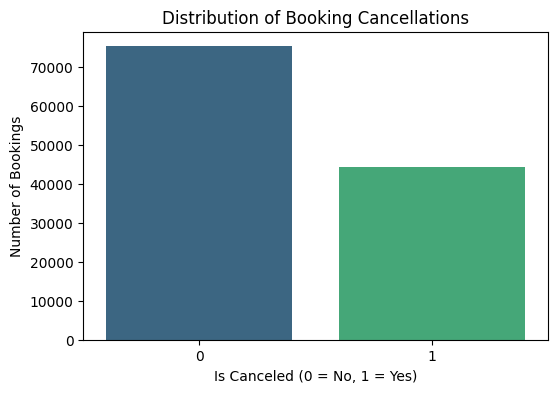


--- Analysis of 'adr' (Average Daily Rate) ---


,adr
count,119390.000000
mean,101.831122
std,50.535790
min,-6.380000
25%,69.290000
50%,94.575000
75%,126.000000
max,5400.000000


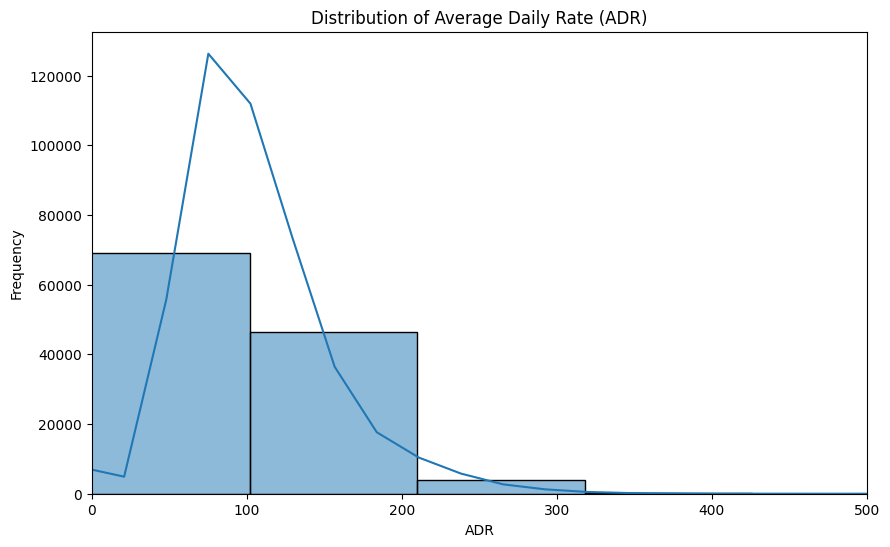


--- Analysis of 'market_segment' ---


,proportion
market_segment,
Online TA,47.3%
Offline TA/TO,20.29%
Groups,16.59%
Direct,10.56%
Corporate,4.44%
Complementary,0.62%
Aviation,0.2%
Undefined,0.0%


/tmp/ipython-input-1647603963.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='market_segment', order=df['market_segment'].value_counts().index, palette='magma')


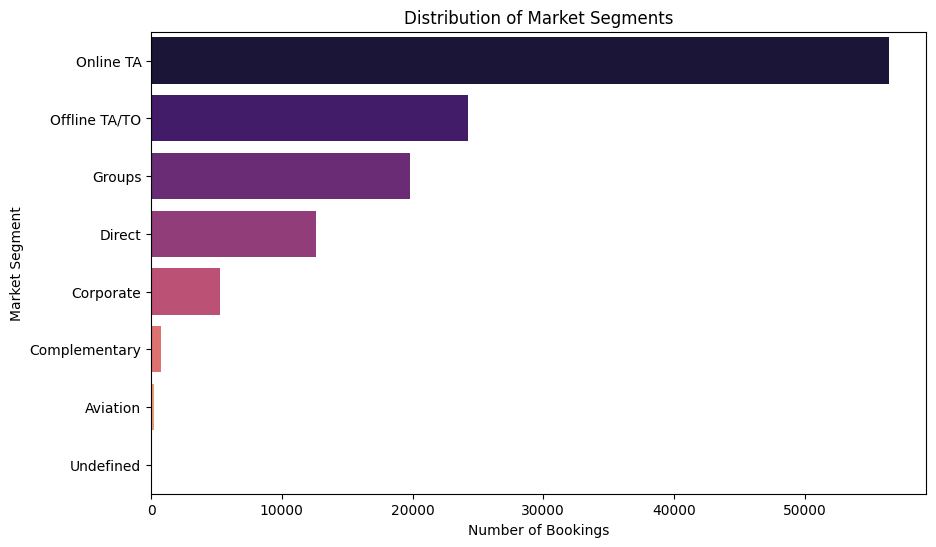

In [4]:
# Variable 1: is_canceled
print("\n--- Analysis of 'is_canceled' ---")
display(df['is_canceled'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='is_canceled', palette='viridis')
plt.title('Distribution of Booking Cancellations')
plt.xlabel('Is Canceled (0 = No, 1 = Yes)')
plt.ylabel('Number of Bookings')
plt.show()

# Variable 2: adr (Average Daily Rate)
print("\n--- Analysis of 'adr' (Average Daily Rate) ---")
display(df['adr'].describe())

plt.figure(figsize=(10, 6))
sns.histplot(df['adr'], bins=50, kde=True)
plt.title('Distribution of Average Daily Rate (ADR)')
plt.xlabel('ADR')
plt.ylabel('Frequency')
plt.xlim(0, 500) # Limiting x-axis for better visualization of main distribution
plt.show()

# Variable 3: market_segment
print("\n--- Analysis of 'market_segment' ---")
display(df['market_segment'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

plt.figure(figsize=(10, 6))
sns.countplot(data=df, y='market_segment', order=df['market_segment'].value_counts().index, palette='magma')
plt.title('Distribution of Market Segments')
plt.xlabel('Number of Bookings')
plt.ylabel('Market Segment')
plt.show()

### In Your Response:
1. Variable 1 – What did you explore and what did you find?
2. Variable 2 – What did you explore and what did you find?
3. Variable 3 – What did you explore and what did you find?

### ✍️ Your Response: 🔧
- **Variable 1 – Summary and insights:**  I looked at the cancellation rate for the hotel. The variable is_canceled shows the proportion of about 37% of bookings end up canceling the stay.
- **Variable 2 – Summary and insights:**  Next I looked at the Average Daily Rate for the hotel. The mean rate is just over $100, with a standard deviation of $50. The max rate is $5,400 and the minimum shows as $-6, while the median is about $94 meaning the data is slightly right skewed.
- **Variable 3 – Summary and insights:**  Finally, I looked at the market segments of customers. In the market_segment data it shows that the majority, 47%, comes from online travel agencies, with the next most, 20%, coming from offline travel companies. The next most were groups of people coming in at about 16%.


## 5. Bivariate Analysis

### Business framing:  

Stakeholders often ask: “What drives cancellations?” or “Do longer stays mean higher revenue?” Bivariate analysis helps you uncover those kinds of relationships.

### Do the following:
- Choose 2 relevant variable pairs (e.g., `lead_time` vs. `is_canceled`, or `adr` vs. `customer_type`)
- Use scatterplots, grouped bar plots, or boxplots to explore the relationships
- Interpret what these relationships could mean for the hotel business


--- Analysis of Lead Time vs. Cancellation Rate ---


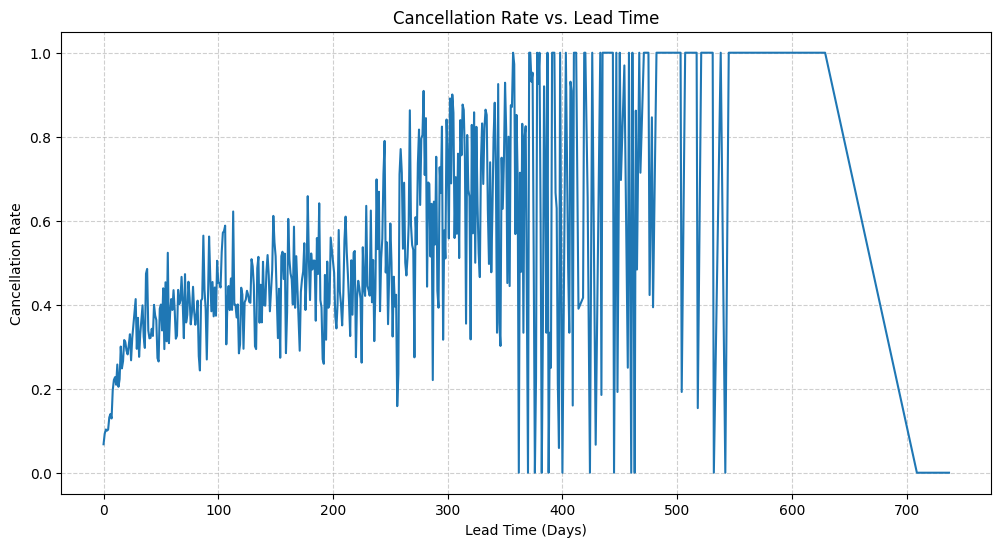


--- Analysis of Market Segment vs. Cancellation Rate ---


/tmp/ipython-input-2309623707.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cancellation_by_market_segment, x='is_canceled', y='market_segment', palette='plasma')


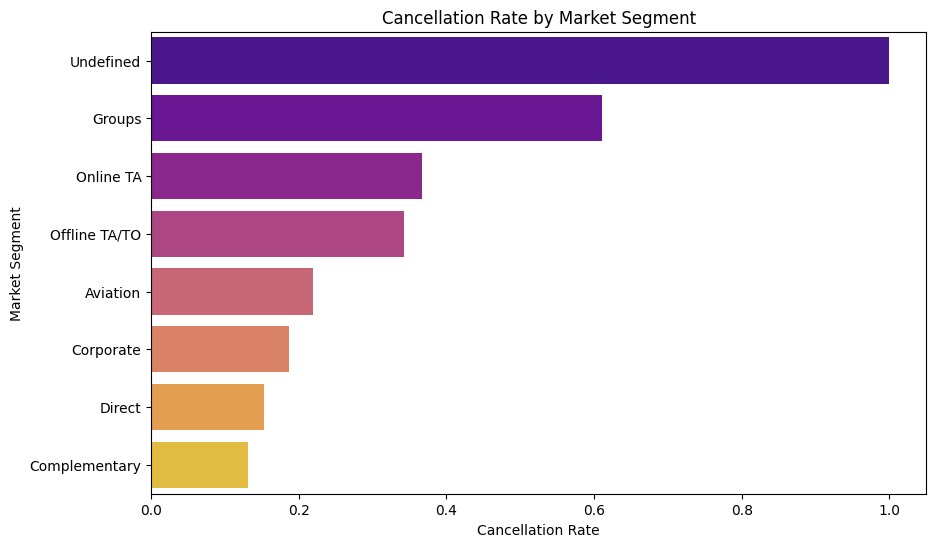

In [5]:
# Relationship 1: lead_time vs. is_canceled
print("\n--- Analysis of Lead Time vs. Cancellation Rate ---")
# Calculate cancellation rate per lead time
cancellation_by_lead_time = df.groupby('lead_time')['is_canceled'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(data=cancellation_by_lead_time, x='lead_time', y='is_canceled')
plt.title('Cancellation Rate vs. Lead Time')
plt.xlabel('Lead Time (Days)')
plt.ylabel('Cancellation Rate')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Relationship 2: market_segment vs. is_canceled
print("\n--- Analysis of Market Segment vs. Cancellation Rate ---")
# Calculate cancellation rate per market segment
cancellation_by_market_segment = df.groupby('market_segment')['is_canceled'].mean().reset_index()

# Sort by cancellation rate for better visualization
cancellation_by_market_segment = cancellation_by_market_segment.sort_values(by='is_canceled', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=cancellation_by_market_segment, x='is_canceled', y='market_segment', palette='plasma')
plt.title('Cancellation Rate by Market Segment')
plt.xlabel('Cancellation Rate')
plt.ylabel('Market Segment')
plt.show()

### In Your Response:
1. Relationship 1 – What did you analyze and what insights did you find?
2. Relationship 2 – What did you analyze and what insights did you find?

### ✍️ Your Response: 🔧
- **Relationship 1:**  I looked at the cancellation rate vs. lead time of the hotel booking. Under one year of lead time the cancellation rate hovered between 35-45% a majority of the time and rises to over 60% as it approaches the annual mark. After one year the data almost looks like it is binary and the lines go back and forth between 1 and 0 meaning it is more difficult to determine the cancellation percentage after this amount of time. The cancellation is more likely to happen after this amount of time, especially after about 475 days where almost all of the bookings are canceled through about the 635 day mark.
- **Relationship 2:**  Next I looked at the cancellation rate by market segment. The undefined market segment shows a strong indication of cancellation at almost 100% and may need to investigate further to fully understand what is going on with this data. The next highest segment that cancels is groups of people or organizations booking many rooms at a time at 60% and online travel companies at 40%.


## 6. Problem Complexity and Analytics Framing

### Business framing:  

Let’s say you found a strong trend — maybe high lead times predict cancellations, or certain channels bring repeat guests. What kind of problem is this?

- Choose one insight from your earlier analysis
- Reflect on:
  - What type of complexity this problem represents (e.g., variety, volume, variability)
  - What kind of analytics would help solve or explain it (descriptive, diagnostic, predictive, prescriptive)

### In Your Response:
1. What was your selected insight?
2. What kind of complexity does it involve?
3. What type of analytics would help, and why?



### ✍️ Your Response: 🔧
1. When a booking is made with a longer lead time it is significantly more likely to be canceled than bookings made closer to arrival date.
2. This problem involves variablility because the customer behavior changes depending on how far in advance the booking is, which creates uncertainty. Customers price shop, plans can change, or some type of work or weather related issue could get in the way of fulfillment. It also varies on where the customer books the stay from. But the core challenge is unpredictable outcomes over time.
3. Predictive analytics such as logistic regression could help determine if a customer is likely to cancel based on lead time or other variables. Diagnostic analytics could help explain why long lead times lead to cancellations by comparing cancellation rates across lead time buckets, identifying behavioral drivers, and analyzing interactions with deposit type or channel. Finally, prescriptive analytics would mitigate risk by recommending actions such as requiring a depost for longer lead times, allowing controlled overbookings, and offering incentive for confirmation when approaching the arrival date.



## 7. Final Takeaways and Recommendations

### Business framing:  

Imagine you’re preparing for a stakeholder meeting. What would you highlight from your findings?

- Identify your top 2–3 insights or patterns
- Connect each to a stakeholder need or business goal
- Make one recommendation based on the analysis

### In Your Response:
1. What patterns or trends stood out?
2. How do they connect to stakeholder goals?
3. What recommendation would you make based on this analysis?
4. How does this relate to your customized learning outcome you created in canvas?



### ✍️ Your Response: 🔧

1. The first trend shown in the analysis is that longer lead times lead to higher cancellation rates. The distribution channel where the lead books from can help predict how loyal a customer will be. And the deposit type has an impact on reducing cancellation rate.

2. The lead time and deposit insights help reduce last minute empty rooms for executive and management goals. Understanding predictable cancellation patterns support smarter overbooking decisions for revenue and finance goals. Channel insights reveal where loyalty actually comes from for the marketing team. With fewer cancellation it will help to improve labor and room allocation for the operations department.

3. I would recommend that we implement a tiered booking policy that combines lead time, channel, and deposit requirements to reduce cancellation risk while preserving booking volume.

4. This project relates directly to my customized learning outcomes for the class because it helps me to frame business problems clearly and translate them into analytical questions that support investment decisions, assess risk, and consult in improving the management of the business. I was also able to build and evaluate predictive models to contribute good data to contribute in making good decisions for the company.

## Submission Instructions

✅ **Before submitting:**
- Make sure all code cells are run and outputs are visible  
- All markdown questions are answered thoughtfully  
- Submit the assignment as an **HTML file** on Canvas


In [6]:
!jupyter nbconvert --to html "assignment_05_MarcroftParker.ipynb"

[NbConvertApp] Converting notebook assignment_05_MarcroftParker.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 5 image(s).
[NbConvertApp] Writing 659528 bytes to assignment_05_MarcroftParker.html
